# Customer Churn Model Improvement

## 1. Project Goal

The goal of this notebook is to improve the customer churn prediction model by focusing on churn recall and F1-score.

The previous notebook showed that Logistic Regression performed better than Random Forest, but the model still missed many customers who actually churned. In this notebook, class weighting and Random Forest tuning will be tested to improve churn prediction.

## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score, f1_score, precision_score

## 3. Load processed dataset

In [2]:
df = pd.read_csv('../data/processed/model_ready_data.csv')
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,0,1,29,29,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56,1889,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53,108,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42,1840,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70,151,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


In [3]:
df.shape

(7043, 31)

In [4]:
df["Churn"].value_counts(normalize=True )

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [5]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [6]:
X.head(5)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29,29,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56,1889,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53,108,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42,1840,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70,151,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


## 4. Train/test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Training set shape: (5634, 30)
Testing set shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


## 5. Baseline Logistic Regression

This model is used as the baseline. The improved models will be compared against this result.

In [29]:
baseline_log_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_log_model.fit(X_train, y_train) 

baseline_log_predictions = baseline_log_model.predict(X_test)

baseline_log_accuracy = accuracy_score(y_test, baseline_log_predictions)
baseline_log_precision = precision_score(y_test, baseline_log_predictions)
baseline_log_recall = recall_score(y_test, baseline_log_predictions)
baseline_log_f1 = f1_score(y_test, baseline_log_predictions)

print("Baseline Logistic Regression Performance:")
print(f"Accuracy: {baseline_log_accuracy:.4f}")
print(f"Precision: {baseline_log_precision:.4f}")
print(f"Recall: {baseline_log_recall:.4f}")
print(f"F1 Score: {baseline_log_f1:.4f}")

Baseline Logistic Regression Performance:
Accuracy: 0.8041
Precision: 0.6541
Recall: 0.5561
F1 Score: 0.6012


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
baseline_log_conf_matrix = confusion_matrix(y_test, baseline_log_predictions)
baseline_log_conf_matrix

array([[925, 110],
       [166, 208]])

In [10]:
baseline_log_class_report = classification_report(y_test, baseline_log_predictions)
print("Classification Report:")
print(baseline_log_class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



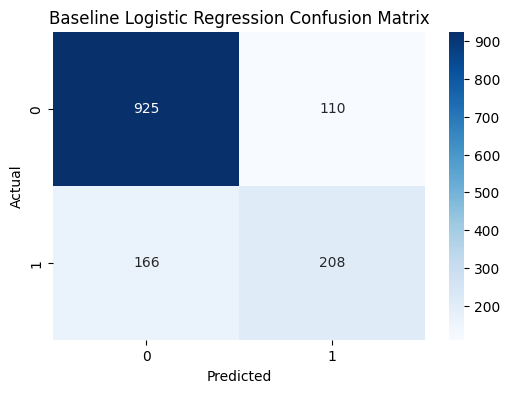

In [11]:
plt.figure(figsize=(6,4))
sns.heatmap(baseline_log_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Baseline Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The baseline Logistic Regression model correctly identified 208 churn customers but missed 166 customers who actually churned. Since the main goal of churn prediction is to identify customers who may leave, improving churn recall will be important in the next models.

## 6. Logistic Regression with Class Weight

In [12]:
weighted_log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
weighted_log_model.fit(X_train, y_train)

weighted_log_predictions = weighted_log_model.predict(X_test)

weighted_log_accuracy = accuracy_score(y_test, weighted_log_predictions)
weighted_log_precision = precision_score(y_test, weighted_log_predictions)
weighted_log_recall = recall_score(y_test, weighted_log_predictions)
weighted_log_f1 = f1_score(y_test, weighted_log_predictions)
print("Weighted Logistic Regression Performance:")
print(f"Accuracy: {weighted_log_accuracy:.4f}")
print(f"Precision: {weighted_log_precision:.4f}")
print(f"Recall: {weighted_log_recall:.4f}")
print(f"F1 Score: {weighted_log_f1:.4f}")

Weighted Logistic Regression Performance:
Accuracy: 0.7374
Precision: 0.5034
Recall: 0.7888
F1 Score: 0.6146


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
weighted_log_confusion_matrix = confusion_matrix(y_test, weighted_log_predictions)
print("Confusion Matrix:")
print(weighted_log_confusion_matrix)

Confusion Matrix:
[[744 291]
 [ 79 295]]


In [16]:
weighted_log_class_report = classification_report(y_test, weighted_log_predictions)
print("Classification Report:")
print(weighted_log_class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



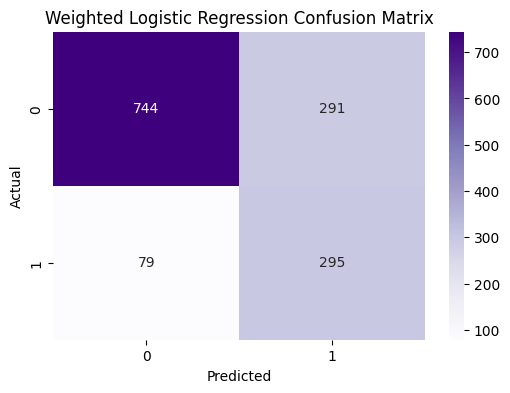

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(weighted_log_confusion_matrix, annot=True, fmt='d', cmap='Purples')
plt.title('Weighted Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Using `class_weight="balanced"` significantly improved churn recall. The model missed only 79 churn customers compared with 166 missed by the baseline Logistic Regression model. However, this improvement came with a trade-off: the model also produced more false churn predictions for customers who did not actually churn. This shows that class weighting can help identify more at-risk customers, but it may reduce precision.

## 7. Random Forest with Class Weight

In [18]:
weighted_rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
weighted_rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
weighted_rf_predictions = weighted_rf_model.predict(X_test)

weighted_rf_accuracy = accuracy_score(y_test, weighted_rf_predictions)
weighted_rf_precision = precision_score(y_test, weighted_rf_predictions)
weighted_rf_recall = recall_score(y_test, weighted_rf_predictions)  
weighted_rf_f1 = f1_score(y_test, weighted_rf_predictions)

print("Weighted Random Forest Performance:")
print(f"Accuracy: {weighted_rf_accuracy:.4f}")
print(f"Precision: {weighted_rf_precision:.4f}")
print(f"Recall: {weighted_rf_recall:.4f}")
print(f"F1 Score: {weighted_rf_f1:.4f}")

Weighted Random Forest Performance:
Accuracy: 0.7878
Precision: 0.6254
Recall: 0.5000
F1 Score: 0.5557


In [20]:
weighted_rf_conf_matrix = confusion_matrix(y_test, weighted_rf_predictions)
print("Confusion Matrix:")
print(weighted_rf_conf_matrix)

Confusion Matrix:
[[923 112]
 [187 187]]


In [21]:
weighted_rf_class_report = classification_report(y_test, weighted_rf_predictions)
print("Classification Report:")
print(weighted_rf_class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



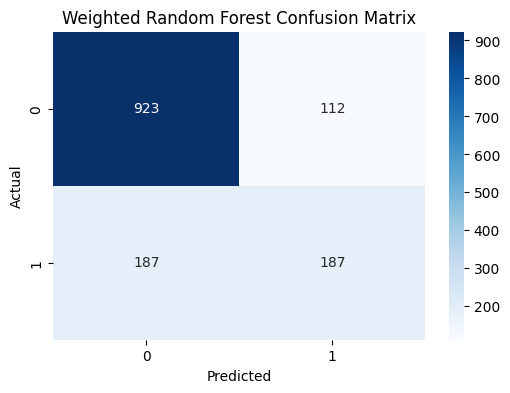

In [22]:
plt.figure(figsize=(6,4))
sns.heatmap(weighted_rf_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Weighted Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The Weighted Random Forest model did not improve churn recall. It missed 187 churn customers, which is worse than both the baseline Logistic Regression model and the Weighted Logistic Regression model. This shows that class weighting does not always improve every model. In this project, class weighting helped Logistic Regression much more than Random Forest.

## 8. Random Forest Hyperparameter Tuning

In this section, Random Forest hyperparameter tuning is performed using GridSearchCV. The goal is to test different model settings and find a Random Forest version with better churn recall and F1-score.

In [23]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth' :[5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

In [24]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42), 
    param_grid=param_grid, 
    scoring='recall',
    cv=3, 
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [25]:
print("Best Hyperparameters:", rf_grid.best_params_)
print("Best Recall Score:", rf_grid.best_score_)

Best Hyperparameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Recall Score: 0.8133898318725805


In [26]:
tuned_rf_model = rf_grid.best_estimator_
tuned_rf_predictions = tuned_rf_model.predict(X_test)

tuned_rf_accuracy = accuracy_score(y_test, tuned_rf_predictions)
tuned_rf_precision = precision_score(y_test, tuned_rf_predictions)
tuned_rf_recall = recall_score(y_test, tuned_rf_predictions)
tuned_rf_f1 = f1_score(y_test, tuned_rf_predictions)

print("Tuned Random Forest Performance:")
print(f"Accuracy: {tuned_rf_accuracy:.4f}")
print(f"Precision: {tuned_rf_precision:.4f}")
print(f"Recall: {tuned_rf_recall:.4f}")
print(f"F1 Score: {tuned_rf_f1:.4f}")

Tuned Random Forest Performance:
Accuracy: 0.7317
Precision: 0.4967
Recall: 0.8155
F1 Score: 0.6174


In [27]:
tuned_rf_conf_matrix = confusion_matrix(y_test, tuned_rf_predictions)
print("Confusion Matrix:")
print(tuned_rf_conf_matrix)

Confusion Matrix:
[[726 309]
 [ 69 305]]


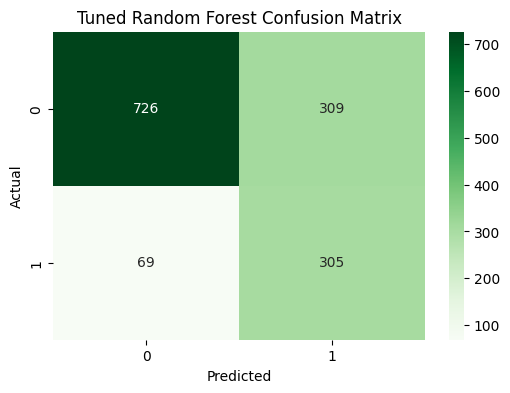

In [28]:
plt.figure(figsize=(6,4))
sns.heatmap(tuned_rf_conf_matrix, annot=True, fmt='d', cmap='Greens')
plt.title('Tuned Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


The Tuned Random Forest model achieved the best churn recall so far. It missed only 69 churn customers, compared with 166 missed by the baseline Logistic Regression model and 79 missed by the Weighted Logistic Regression model. However, this improvement came with a trade-off: the model produced more false positives, incorrectly flagging 309 non-churn customers as churn risk. This model may be useful when the business goal is to identify as many at-risk customers as possible.

## 9. Model Comparison

In this section, all tested models are compared using accuracy, precision, recall, and F1-score. Since this is a churn prediction project, recall for the churn class is especially important because the goal is to identify as many customers who may leave as possible.

In [31]:
model_results = pd.DataFrame({
    'Model': ['Baseline Logistic Regression', 'Weighted Logistic Regression', 'Weighted Random Forest', 'Tuned Random Forest'],
    'Accuracy': [baseline_log_accuracy, weighted_log_accuracy, weighted_rf_accuracy, tuned_rf_accuracy],
    'Precision': [baseline_log_precision, weighted_log_precision, weighted_rf_precision, tuned_rf_precision],
    'Recall': [baseline_log_recall, weighted_log_recall, weighted_rf_recall, tuned_rf_recall],
    'F1 Score': [baseline_log_f1, weighted_log_f1, weighted_rf_f1, tuned_rf_f1]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Logistic Regression,0.804116,0.654088,0.556150,0.601156
1,Weighted Logistic Regression,0.737402,0.503413,0.788770,0.614583
2,Weighted Random Forest,0.787793,0.625418,0.500000,0.555721
3,Tuned Random Forest,0.731725,0.496743,0.815508,0.617409


C:\Users\user\AppData\Local\Temp\ipykernel_10700\3230033979.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Recall', data=model_results, palette='Set2')


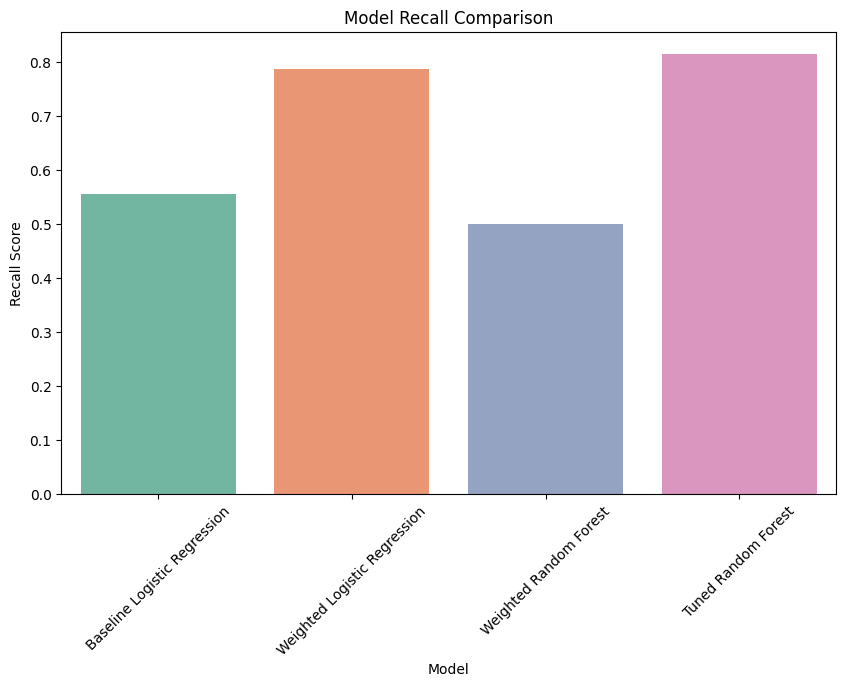

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='Recall', data=model_results, palette='Set2')
plt.title('Model Recall Comparison')
plt.ylabel('Recall Score')
plt.xticks(rotation=45)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_10700\2443581602.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1 Score', data=model_results, palette='Set2')


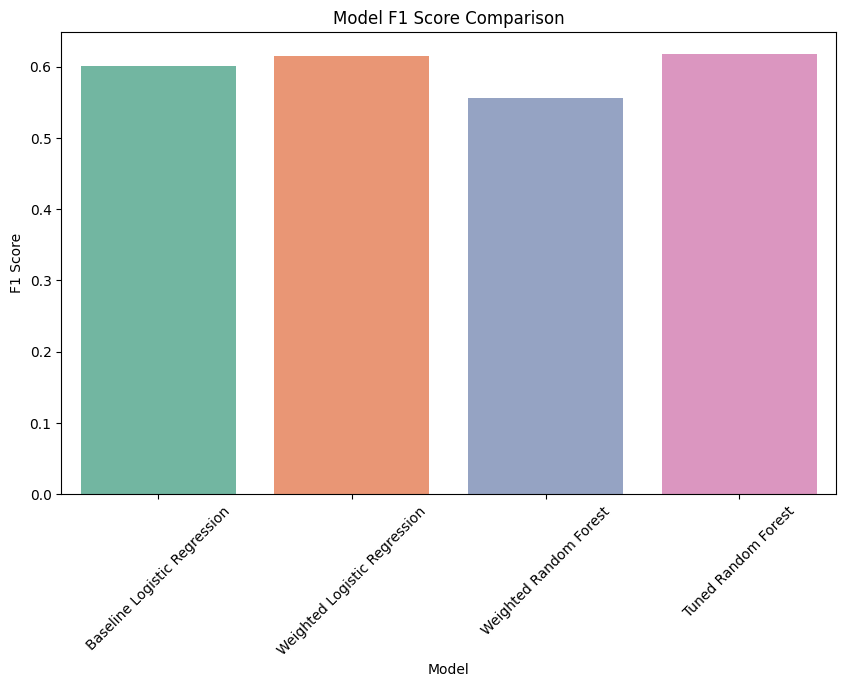

In [33]:
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='F1 Score', data=model_results, palette='Set2')
plt.title('Model F1 Score Comparison')
plt.ylabel('F1 Score')
plt.xticks(rotation=45)
plt.show()

The Tuned Random Forest model achieved the highest churn recall, meaning it identified the largest number of customers who actually churned. It missed only 69 churn customers, compared with 166 missed by the baseline Logistic Regression model. However, this model also produced more false positives, meaning it incorrectly flagged more non-churn customers as churn risk. If the business goal is to catch as many at-risk customers as possible, the Tuned Random Forest is the best model. If the business wants fewer false alarms, Weighted Logistic Regression may be a more balanced option.

## 10. Final Findings

This notebook focused on improving customer churn prediction by testing class weighting and Random Forest hyperparameter tuning.

Key findings:

- The baseline Logistic Regression model missed 166 churn customers.
- Weighted Logistic Regression improved churn recall and missed only 79 churn customers.
- Weighted Random Forest did not improve churn recall and missed 187 churn customers.
- Tuned Random Forest achieved the best churn recall and missed only 69 churn customers.
- The Tuned Random Forest model identified the largest number of actual churn customers.
- The improvement came with a trade-off: Tuned Random Forest also produced more false positives.
- If the business goal is to catch as many at-risk customers as possible, Tuned Random Forest is the best model.
- If the business wants fewer false alarms, Weighted Logistic Regression may be a more balanced option.

Overall, this notebook showed that model improvement is not only about increasing accuracy. For churn prediction, recall is especially important because the business wants to find customers who are likely to leave. Class weighting and hyperparameter tuning can significantly change model behavior and should be evaluated based on the business goal.